# 07 Business Impact and Model Interpretation

This notebook translates the final SupplyGuard machine learning results into business insight.

The model was already selected and evaluated in Notebook 06 using a leakage-safe workflow, with a Random Forest classifier and a validation-selected threshold of 0.16. This notebook does not retrain the model, change the threshold or repeat previous analysis.

Instead, it focuses on interpreting what the model means for operations: how well it concentrates late-delivery risk, which order segments should be prioritized, how to understand false positives and false negatives, and how the results can support dashboard design, business recommendations and future improvements.

## Load Model Outputs

The notebook starts from the saved model outputs created in Notebook 06.

In [73]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [74]:
# Project palette and visual settings

sns.set_theme(style="whitegrid", context="notebook")

project_palette = {
    "deep_navy": "#1D2D44", "slate_blue": "#3E5C76", "soft_blue": "#A9BCD0",
    "forest": "#2F5D50", "sage": "#A3B18A", "sand": "#D8C3A5",
    "clay": "#C97C5D", "terracotta": "#B85C38", "amber": "#D99A3D",
    "warm_gray": "#8A817C", "charcoal": "#2F2F2F", "off_white": "#F7F8F5"
}

status_palette = {"On-time": project_palette["forest"], "Late": project_palette["terracotta"]}

relation_palette = {
    "Same state": project_palette["soft_blue"],
    "Cross-state": project_palette["deep_navy"]
}

risk_band_colors = {
    "Low Risk": project_palette["sage"],
    "Medium Risk": project_palette["sand"],
    "High Risk": project_palette["clay"],
    "Very High Risk": project_palette["terracotta"]
}

geo_palette = [project_palette["sand"], project_palette["clay"], project_palette["terracotta"], project_palette["deep_navy"]]
econ_palette = [project_palette["soft_blue"], project_palette["slate_blue"], project_palette["deep_navy"]]
review_palette = [project_palette["terracotta"], project_palette["amber"], project_palette["sage"], project_palette["forest"]]

main_color = project_palette["slate_blue"]
baseline_color = project_palette["warm_gray"]
threshold_color = project_palette["terracotta"]
text_color = project_palette["charcoal"]

In [75]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

outputs_path = project_root / "outputs"
processed_path = project_root / "data" / "processed"

model_results_path = outputs_path / "model_comparison_results.csv"
test_predictions_path = outputs_path / "test_predictions.csv"
best_model_path = outputs_path / "best_model.pkl"
modeling_data_path = processed_path / "modeling_dataset.csv"
feature_dictionary_path = processed_path / "feature_dictionary.csv"

model_results = pd.read_csv(model_results_path)
test_predictions = pd.read_csv(test_predictions_path)
modeling_df = pd.read_csv(modeling_data_path)
feature_dictionary = pd.read_csv(feature_dictionary_path)
best_model = joblib.load(best_model_path)

print(f"Model results: {model_results.shape}")
print(f"Test predictions: {test_predictions.shape}")
print(f"Modeling dataset: {modeling_df.shape}")
print(f"Feature dictionary: {feature_dictionary.shape}")

Model results: (7, 10)
Test predictions: (19294, 4)
Modeling dataset: (96470, 35)
Feature dictionary: (35, 3)


In [76]:
final_model_results = model_results[model_results["threshold"].notna()].copy()
validation_model_results = model_results[model_results["threshold"].isna()].copy()

print("Model comparison:")
display(validation_model_results[["model", "accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]])

print("\nFinal model selected:")
display(final_model_results[["model", "threshold", "accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc", "predicted_late_orders", "actual_late_orders"]])

print("\nExample predictions:")
display(test_predictions.head())

Model comparison:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Dummy Classifier,0.9323,0.0000,0.0000,0.0000,0.5000,0.0677
1,Logistic Regression,0.6950,0.1416,0.6917,0.2350,0.7628,0.2231
2,Decision Tree,0.8812,0.1735,0.2005,0.1860,0.5655,0.0889
3,Random Forest,0.9328,0.8571,0.0092,0.0182,0.7563,0.2535
4,Extra Trees,0.9326,0.5385,0.0321,0.0606,0.7479,0.2214
5,Random Forest Tuned,0.7938,0.1775,0.5624,0.2698,0.7652,0.2384



Final model selected:


,model,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,predicted_late_orders,actual_late_orders
6,Random Forest,0.16,0.8991,0.2914,0.342,0.3147,0.762,0.2384,1534.0,1307.0



Example predictions:


,order_id,actual_is_late,late_risk_score,predicted_is_late
0,d749b12b674090063683ff90a811c2b9,0,0.025,0
1,93c5ca94a86b96968decd0a16f17ef60,0,0.075,0
2,089b005e56c360e749ff7185aa4814af,0,0.090,0
3,7701ecd93e987006334fba168c936f20,1,0.105,0
4,4e2be877bb8fb4d51fc622a758abb7d9,0,0.035,0


## Final Model Performance Recap

The final model is interpreted as a risk-prioritization layer, not as a complete late-delivery detection system.

In [77]:
final_row = final_model_results.iloc[0]

baseline_late_rate = test_predictions["actual_is_late"].mean()
alert_rate = test_predictions["predicted_is_late"].mean()
flagged_late_rate = test_predictions.loc[test_predictions["predicted_is_late"] == 1, "actual_is_late"].mean()
lift_vs_baseline = flagged_late_rate / baseline_late_rate

performance_summary = pd.DataFrame([{
    "baseline_late_rate_pct": round(baseline_late_rate * 100, 2),
    "selected_threshold": final_row["threshold"],
    "flagged_orders": int(final_row["predicted_late_orders"]),
    "alert_rate_pct": round(alert_rate * 100, 2),
    "flagged_late_rate_pct": round(flagged_late_rate * 100, 2),
    "lift_vs_baseline": round(lift_vs_baseline, 2),
    "recall_pct": round(final_row["recall"] * 100, 2),
    "f1_score_pct": round(final_row["f1_score"] * 100, 2),
    "pr_auc_pct": round(final_row["pr_auc"] * 100, 2)
}])

print("Final model business summary:")
display(performance_summary)

Final model business summary:


,baseline_late_rate_pct,selected_threshold,flagged_orders,alert_rate_pct,flagged_late_rate_pct,lift_vs_baseline,recall_pct,f1_score_pct,pr_auc_pct
0,6.77,0.16,1534,7.95,29.14,4.3,34.2,31.47,23.84


In [78]:
confusion_summary = pd.crosstab(
    test_predictions["actual_is_late"],
    test_predictions["predicted_is_late"],
    rownames=["Actual"],
    colnames=["Predicted"]
).rename(index={0: "On Time", 1: "Late"}, columns={0: "On Time", 1: "Late"})

print("Confusion matrix:")
display(confusion_summary)

Confusion matrix:


Predicted,On Time,Late
Actual,,
On Time,16900,1087
Late,860,447


At the selected threshold of 0.16, the model flags 7.95% of test orders for operational attention. These flagged orders have a 29.14% late-delivery rate, compared with the 6.77% baseline, giving a 4.3x lift over random prioritization.

This confirms that the model is useful as a risk-prioritization layer, although it does not capture all late deliveries.

## Risk Score Distribution

The risk score distribution shows how conservative the model is when assigning late-delivery probabilities.

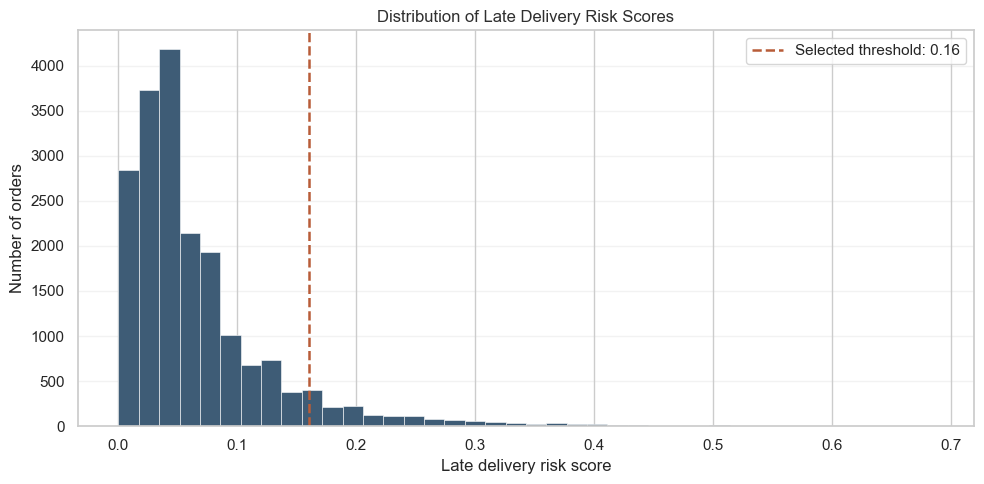

In [79]:
plt.figure(figsize=(10, 5))

plt.hist(test_predictions["late_risk_score"], bins=40, color=main_color, edgecolor="white", linewidth=0.4)
plt.axvline(0.16, color=threshold_color, linestyle="--", linewidth=1.8, label="Selected threshold: 0.16")

plt.title("Distribution of Late Delivery Risk Scores", color=text_color)
plt.xlabel("Late delivery risk score")
plt.ylabel("Number of orders")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Risk Bands

Risk bands translate model scores into operational segments.

In [80]:
risk_bins = [-np.inf, 0.08, 0.16, 0.25, np.inf]
risk_labels = ["Low Risk", "Medium Risk", "High Risk", "Very High Risk"]

test_predictions["risk_band"] = pd.cut(test_predictions["late_risk_score"], bins=risk_bins, labels=risk_labels, right=False)

risk_band_summary = test_predictions.groupby("risk_band", observed=True).agg(
    orders=("order_id", "count"),
    late_orders=("actual_is_late", "sum"),
    late_rate=("actual_is_late", "mean"),
    avg_risk_score=("late_risk_score", "mean")
).reset_index()

risk_band_summary["order_share_pct"] = (risk_band_summary["orders"] / len(test_predictions) * 100).round(2)
risk_band_summary["late_rate_pct"] = (risk_band_summary["late_rate"] * 100).round(2)
risk_band_summary["avg_risk_score"] = risk_band_summary["avg_risk_score"].round(3)
risk_band_summary["lift_vs_baseline"] = (risk_band_summary["late_rate"] / baseline_late_rate).round(2)
risk_band_summary["late_capture_pct"] = (risk_band_summary["late_orders"] / test_predictions["actual_is_late"].sum() * 100).round(2)

print("Late delivery risk by band:")
display(risk_band_summary[["risk_band", "orders", "order_share_pct", "late_orders", "late_capture_pct", "late_rate_pct", "lift_vs_baseline", "avg_risk_score"]])

Late delivery risk by band:


,risk_band,orders,order_share_pct,late_orders,late_capture_pct,late_rate_pct,lift_vs_baseline,avg_risk_score
0,Low Risk,13992,72.52,481,36.80,3.44,0.51,0.036
1,Medium Risk,3768,19.53,379,29.00,10.06,1.48,0.108
2,High Risk,1014,5.26,239,18.29,23.57,3.48,0.193
3,Very High Risk,520,2.70,208,15.91,40.00,5.90,0.333


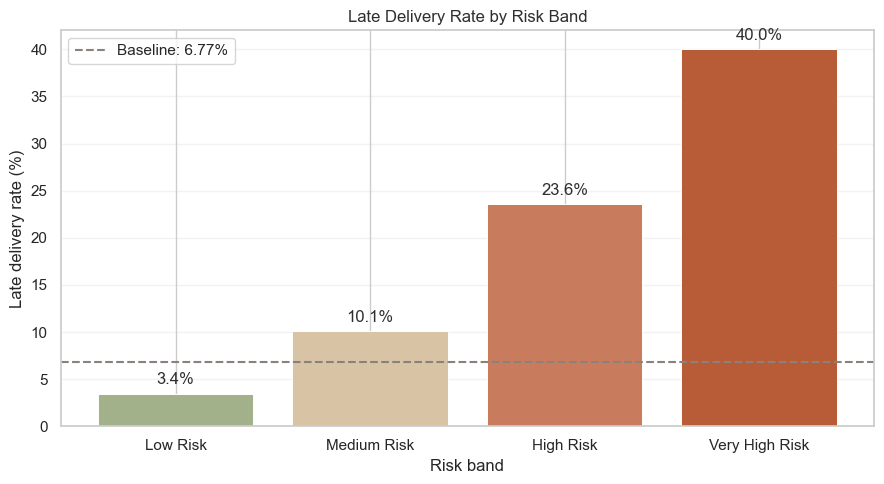

In [81]:
plt.figure(figsize=(9, 5))

risk_band_labels = risk_band_summary["risk_band"].astype(str)
bars = plt.bar(
    risk_band_labels,
    risk_band_summary["late_rate_pct"],
    color=[risk_band_colors[label] for label in risk_band_labels],
    edgecolor="white",
    linewidth=0.7
)

plt.axhline(baseline_late_rate * 100, color=baseline_color, linestyle="--", linewidth=1.5, label=f"Baseline: {baseline_late_rate * 100:.2f}%")

for bar, value in zip(bars, risk_band_summary["late_rate_pct"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.7, f"{value:.1f}%", ha="center", va="bottom", color=text_color)

plt.title("Late Delivery Rate by Risk Band", color=text_color)
plt.xlabel("Risk band")
plt.ylabel("Late delivery rate (%)")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

The risk bands show a clear operational gradient. Low Risk orders have a late-delivery rate of only 3.44%, while Very High Risk orders reach 40.00%.

The final operating threshold separates Medium Risk from High Risk. Together, High Risk and Very High Risk represent the 1,534 orders flagged by the model and contain 447 actual late deliveries.


## Top-Risk Order Analysis

Top-risk segments show how much late-delivery risk is captured when operations focuses on the highest-scored orders.

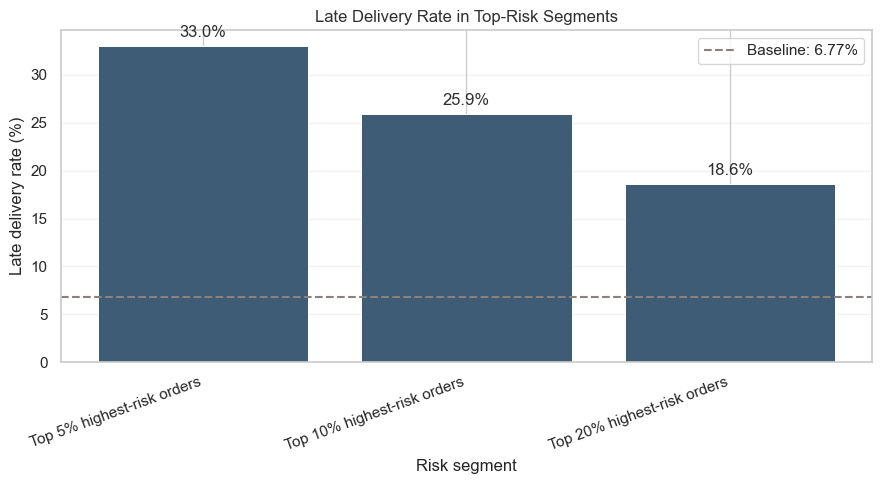

In [82]:
plt.figure(figsize=(9, 5))

bars = plt.bar(top_risk_summary["segment"], top_risk_summary["late_rate_pct"], color=main_color, edgecolor="white", linewidth=0.7)

plt.axhline(baseline_late_rate * 100, color=baseline_color, linestyle="--", linewidth=1.5, label=f"Baseline: {baseline_late_rate * 100:.2f}%")

for bar, value in zip(bars, top_risk_summary["late_rate_pct"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6, f"{value:.1f}%", ha="center", va="bottom", color=text_color)

plt.title("Late Delivery Rate in Top-Risk Segments", color=text_color)
plt.xlabel("Risk segment")
plt.ylabel("Late delivery rate (%)")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

The model concentrates late-delivery risk effectively. The top 5% highest-risk orders show a 32.99% late rate, almost 5 times the baseline. Expanding the scope to the top 10% captures 38.26% of all late deliveries while maintaining a late rate of 25.92%.

This supports using the model as an operational prioritization tool: teams can focus on a limited share of orders where late-delivery risk is materially higher than average.

## Feature Importance

Feature importance is used to understand which input areas contribute most to the Random Forest risk ranking. These values should be interpreted as model signals, not as causal effects.

In [83]:
preprocessor = best_model.named_steps["preprocessor"]
rf_model = best_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
input_features = []

for _, _, cols in preprocessor.transformers_:
    input_features.extend(cols)

feature_importance = pd.DataFrame({"transformed_feature": feature_names, "importance": rf_model.feature_importances_})
feature_importance["clean_feature"] = feature_importance["transformed_feature"].str.replace(r"^[^_]+__", "", regex=True)

original_features = []
for clean_feature in feature_importance["clean_feature"]:
    matched_feature = clean_feature
    for col in sorted(input_features, key=len, reverse=True):
        if clean_feature == col or clean_feature.startswith(f"{col}_"):
            matched_feature = col
            break
    original_features.append(matched_feature)

feature_importance["original_feature"] = original_features

feature_importance_summary = (
    feature_importance.groupby("original_feature", as_index=False)
    .agg(importance=("importance", "sum"))
    .sort_values("importance", ascending=False)
)

feature_importance_summary["importance_pct"] = (feature_importance_summary["importance"] / feature_importance_summary["importance"].sum() * 100).round(2)

print("Top feature importance groups:")
display(feature_importance_summary.head(15))

Top feature importance groups:


,original_feature,importance,importance_pct
23,purchase_month,0.100391,10.04
22,purchase_hour,0.064840,6.48
6,dominant_product_category,0.063059,6.31
7,estimated_delivery_days,0.053815,5.38
4,customer_seller_state_pair,0.051364,5.14
3,customer_seller_distance_km,0.048050,4.81
5,customer_state,0.044203,4.42
0,approval_delay_hours,0.043477,4.35
21,purchase_day_of_week,0.039002,3.90
26,total_freight_value,0.038232,3.82


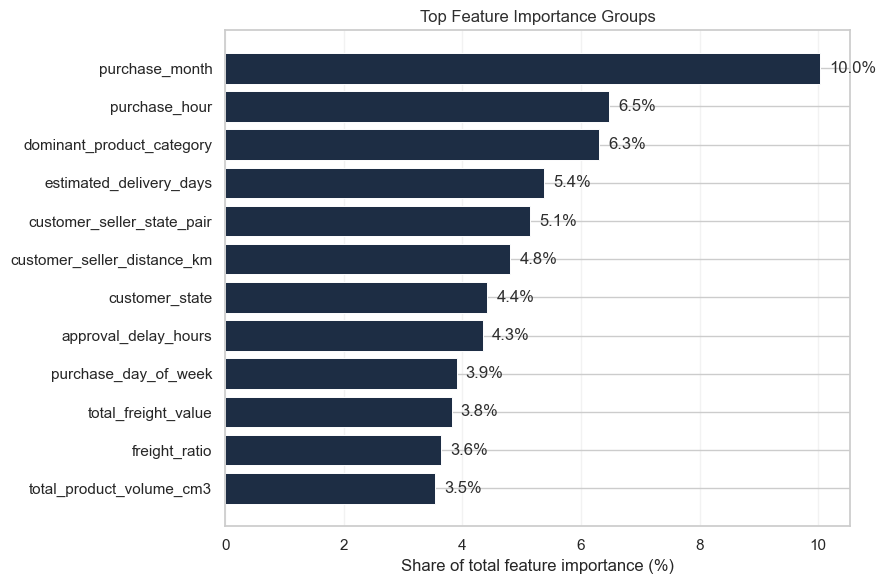

In [84]:
plt.figure(figsize=(9, 6))
bars = plt.barh(top_features["original_feature"], top_features["importance_pct"], color=project_palette["deep_navy"], edgecolor="white", linewidth=0.7)

for bar, value in zip(bars, top_features["importance_pct"]):
    plt.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", color=text_color)

plt.title("Top Feature Importance Groups", color=text_color)
plt.xlabel("Share of total feature importance (%)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

The most important model signals are distributed across purchase timing, product profile, delivery promise, geography, freight complexity and order value.

This is consistent with the EDA: late delivery risk is not explained by one single factor, but by a combination of when the order was placed, where it needs to move, what type of product is involved and how complex or costly the shipment appears to be.

Feature importance should be interpreted as model signal, not as causal impact.

## Feature Importance by Business Area

Feature importance is grouped into business areas to make the model easier to interpret operationally.

In [85]:
feature_area_map = {
    "purchase_month": "Purchase timing", "purchase_hour": "Purchase timing", "purchase_day_of_week": "Purchase timing", "is_weekend_purchase": "Purchase timing",
    "customer_state": "Geography & logistics", "main_seller_state": "Geography & logistics", "customer_seller_state_pair": "Geography & logistics", "customer_seller_distance_km": "Geography & logistics", "same_state_order": "Geography & logistics",
    "estimated_delivery_days": "Delivery promise", "approval_delay_hours": "Delivery promise",
    "dominant_product_category": "Product profile", "product_category_count": "Product profile", "total_product_weight_g": "Product profile", "max_product_weight_g": "Product profile", "total_product_volume_cm3": "Product profile", "max_product_volume_cm3": "Product profile",
    "total_freight_value": "Freight & economics", "freight_ratio": "Freight & economics", "total_item_price": "Freight & economics", "avg_item_price": "Freight & economics", "max_item_price": "Freight & economics", "total_order_item_value": "Freight & economics",
    "payment_count": "Payment profile", "payment_method_count": "Payment profile", "total_payment_value": "Payment profile", "avg_payment_value": "Payment profile", "max_payment_installments": "Payment profile", "main_payment_type": "Payment profile",
    "order_item_count": "Order structure", "product_count": "Order structure", "seller_count": "Order structure"
}

feature_importance_summary["feature_area"] = feature_importance_summary["original_feature"].map(feature_area_map).fillna("Other")

feature_area_summary = (
    feature_importance_summary.groupby("feature_area", as_index=False)
    .agg(importance_pct=("importance_pct", "sum"))
    .sort_values("importance_pct", ascending=False)
)

print("Feature importance by business area:")
display(feature_area_summary)

Feature importance by business area:


,feature_area,importance_pct
6,Purchase timing,21.04
1,Freight & economics,20.86
5,Product profile,20.17
2,Geography & logistics,16.96
4,Payment profile,10.52
0,Delivery promise,9.73
3,Order structure,0.75


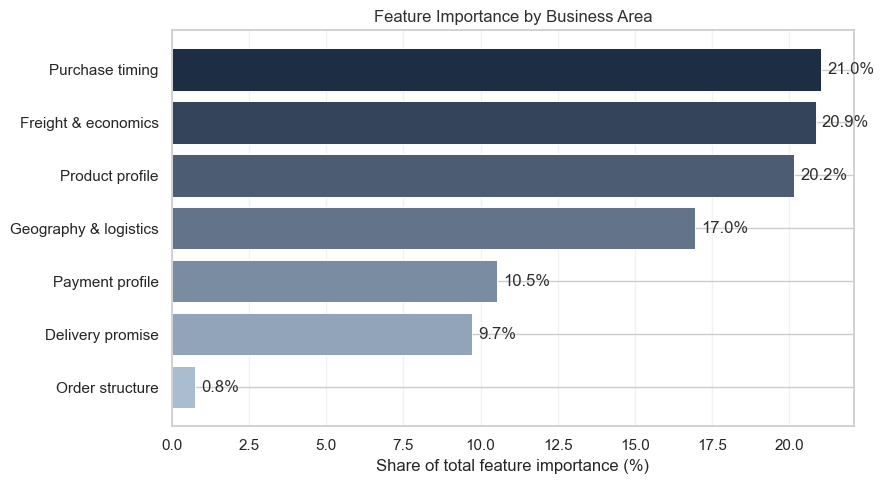

In [86]:
feature_area_plot = feature_area_summary.sort_values("importance_pct")
area_colors = sns.blend_palette([project_palette["soft_blue"], project_palette["deep_navy"]], n_colors=len(feature_area_plot))

plt.figure(figsize=(9, 5))
bars = plt.barh(feature_area_plot["feature_area"], feature_area_plot["importance_pct"], color=area_colors, edgecolor="white", linewidth=0.7)

for bar, value in zip(bars, feature_area_plot["importance_pct"]):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", color=text_color)

plt.title("Feature Importance by Business Area", color=text_color)
plt.xlabel("Share of total feature importance (%)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

The model signal is distributed across several operational areas. Purchase timing, freight/economics, product profile and geography/logistics are the strongest contributors, while payment profile and delivery promise provide additional signal.

This supports the main project interpretation: late delivery risk is not driven by one isolated factor, but by the interaction between when the order is placed, what is being shipped, where it is moving and how complex or costly the order appears to be.

These importances should not be interpreted as causal effects. They describe how the final Random Forest model uses available features to rank delivery risk.

## Prediction Outcome Interpretation

False positives and false negatives are interpreted in operational terms to clarify how the model should be used.

In [88]:
outcome_conditions = [
    (test_predictions["actual_is_late"] == 0) & (test_predictions["predicted_is_late"] == 0),
    (test_predictions["actual_is_late"] == 0) & (test_predictions["predicted_is_late"] == 1),
    (test_predictions["actual_is_late"] == 1) & (test_predictions["predicted_is_late"] == 0),
    (test_predictions["actual_is_late"] == 1) & (test_predictions["predicted_is_late"] == 1)
]

outcome_labels = ["True Negative", "False Positive", "False Negative", "True Positive"]

test_predictions["prediction_outcome"] = np.select(outcome_conditions, outcome_labels, default="Unknown")

outcome_summary = test_predictions.groupby("prediction_outcome", as_index=False).agg(
    orders=("order_id", "count"),
    avg_risk_score=("late_risk_score", "mean")
)

outcome_summary["order_share_pct"] = (outcome_summary["orders"] / len(test_predictions) * 100).round(2)
outcome_summary["avg_risk_score"] = outcome_summary["avg_risk_score"].round(3)

outcome_order = ["True Negative", "False Positive", "False Negative", "True Positive"]
outcome_summary["prediction_outcome"] = pd.Categorical(outcome_summary["prediction_outcome"], categories=outcome_order, ordered=True)
outcome_summary = outcome_summary.sort_values("prediction_outcome")

print("Prediction outcome summary:")
display(outcome_summary)

Prediction outcome summary:


,prediction_outcome,orders,avg_risk_score,order_share_pct
2,True Negative,16900,0.050,87.59
1,False Positive,1087,0.230,5.63
0,False Negative,860,0.076,4.46
3,True Positive,447,0.265,2.32


False positives represent orders flagged for attention that ultimately arrived on time. These cases create unnecessary monitoring effort, but they may be acceptable if the intervention is low-cost.

False negatives are more critical because they represent late deliveries that were not flagged. Their relatively low average risk score suggests that some delivery failures may be driven by factors not available at prediction time, such as carrier issues, warehouse constraints, inventory problems or external disruptions.

This supports the intended use of the model as a prioritization layer rather than a complete late-delivery detection system.

## Business Recommendations

The model should be used as an operational prioritization layer, not as an automatic decision system.

Based on the final model results, SupplyGuard can support three practical use cases:

1. **High-risk order monitoring**  
   Orders classified as High Risk or Very High Risk should be flagged for additional operational review. These orders represent a small share of total volume but contain a much higher concentration of late deliveries than the dataset baseline.

2. **Proactive customer communication**  
   For flagged orders, the company can trigger earlier communication, delivery expectation updates or customer support monitoring. This is especially useful when the cost of intervention is low compared with the potential impact of a late delivery on satisfaction.

3. **Operational performance tracking**  
   The model outputs can feed a dashboard that tracks late delivery rate, risk-band distribution, flagged order volume, precision of alerts and late delivery concentration over time. This helps the company monitor whether logistics performance is improving or deteriorating.

The Streamlit application can use the trained model to score new orders and flag high-risk deliveries, while the dashboard can track the evolution of delivery performance and model-driven risk indicators.

## Dashboard and Streamlit Integration

The final model creates two practical outputs for the business layer:

- a risk score for each order;
- a binary flag based on the selected threshold of 0.16.

In a Streamlit application, these outputs can help operations teams identify which active orders require attention. In a dashboard, the same outputs can be monitored over time to evaluate delivery performance, risk concentration and operational pressure.

Recommended dashboard metrics include:

- overall late delivery rate;
- number and share of flagged orders;
- late rate by risk band;
- precision of flagged orders;
- top-risk order volume;
- late delivery capture rate;
- late rate by customer state, seller state or state pair;
- late rate by freight value segment;
- late rate by product category;
- monthly trend of late delivery rate and flagged order share.

This connects the machine learning workflow with a practical monitoring system for business users.

## Limitations

The model should not be considered production-ready.

Its main limitation is that it only uses information available in the Olist dataset at or shortly after payment approval. It does not include carrier capacity, warehouse workload, inventory status, weather, strikes, real-time tracking events or other external disruptions that may strongly affect delivery outcomes.

The model captures useful risk patterns, but it does not detect all late deliveries. It should therefore support operational prioritization, not replace broader logistics monitoring.

## Save Interpretation Outputs

The main interpretation tables are saved for dashboarding, Streamlit prototyping and final project reporting.

In [90]:
interpretation_outputs = {
    "risk_band_summary.csv": risk_band_summary,
    "top_risk_summary.csv": top_risk_summary,
    "feature_importance_summary.csv": feature_importance_summary,
    "feature_area_summary.csv": feature_area_summary,
    "prediction_outcome_summary.csv": outcome_summary
}

for filename, output_df in interpretation_outputs.items():
    output_df.to_csv(outputs_path / filename, index=False)

test_predictions.to_csv(outputs_path / "test_predictions_with_risk_segments.csv", index=False)

print("Saved interpretation outputs:")
for filename in interpretation_outputs:
    print(outputs_path / filename)
print(outputs_path / "test_predictions_with_risk_segments.csv")

Saved interpretation outputs:
c:\Users\johan\Desktop\supplyguard-delivery-risk\outputs\risk_band_summary.csv
c:\Users\johan\Desktop\supplyguard-delivery-risk\outputs\top_risk_summary.csv
c:\Users\johan\Desktop\supplyguard-delivery-risk\outputs\feature_importance_summary.csv
c:\Users\johan\Desktop\supplyguard-delivery-risk\outputs\feature_area_summary.csv
c:\Users\johan\Desktop\supplyguard-delivery-risk\outputs\prediction_outcome_summary.csv
c:\Users\johan\Desktop\supplyguard-delivery-risk\outputs\test_predictions_with_risk_segments.csv


## Final Conclusions

This notebook translated the final machine learning model into business interpretation.

The Random Forest model should be understood as a risk-prioritization layer. At the selected threshold of 0.16, the model flags 7.95% of test orders and achieves a 29.14% late-delivery rate among flagged orders, compared with a 6.77% baseline. This represents a 4.3x lift over random prioritization.

Risk segmentation confirms that the model creates useful operational groups. Very High Risk orders reach a 40.00% late-delivery rate, while Low Risk orders remain at only 3.44%.

Top-risk analysis also supports the business value of the model: the top 10% highest-risk orders capture 38.26% of all late deliveries while maintaining a 25.92% late rate.

Feature importance suggests that late delivery risk is driven by a combination of purchase timing, freight/economics, product profile, geography/logistics, payment profile and delivery promise. These signals should be interpreted as model behavior, not as causal proof.

The model is not production-ready and should not replace logistics monitoring. Its value is to support prioritization, dashboard monitoring and a future Streamlit tool where business users can flag orders with elevated late-delivery risk.